- The Scenario: You are tasked with building a basic version of Photoshop using only mathematical operations.
- Creating Arrays & Attributes: You load a provided image (using a library like matplotlib.image to read it into a NumPy array). You must inspect .shape, .ndim, and .dtype to understand how the pixels and RGB channels are structured, and create a blank "canvas" using np.zeros().

3742848
(912, 1368, 3)
[[[230 242 242]
  [230 242 242]
  [230 242 242]
  ...
  [228 238 239]
  [229 239 240]
  [229 239 240]]

 [[230 242 242]
  [230 242 242]
  [230 242 242]
  ...
  [228 238 239]
  [229 239 240]
  [229 239 240]]

 [[230 242 242]
  [230 242 242]
  [230 242 242]
  ...
  [229 239 240]
  [229 239 240]
  [229 239 240]]

 ...

 [[ 22  24   2]
  [  9  11   0]
  [ 35  37  13]
  ...
  [ 14  12   0]
  [ 16  14   2]
  [ 15  15   3]]

 [[ 17  20   0]
  [ 26  29   0]
  [ 60  63  32]
  ...
  [ 14  12   0]
  [ 16  14   2]
  [ 17  15   3]]

 [[ 40  44  11]
  [ 54  58  25]
  [ 54  58  25]
  ...
  [ 18  16   4]
  [ 17  15   3]
  [ 17  15   3]]]
3
uint8


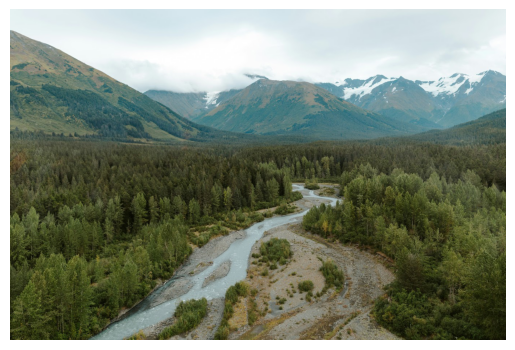

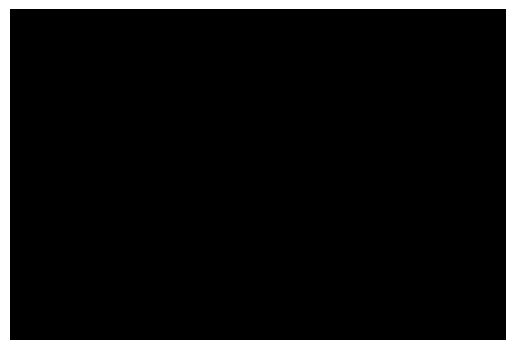

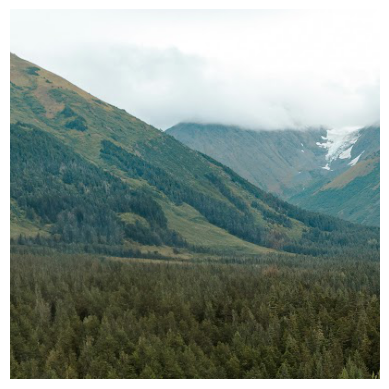

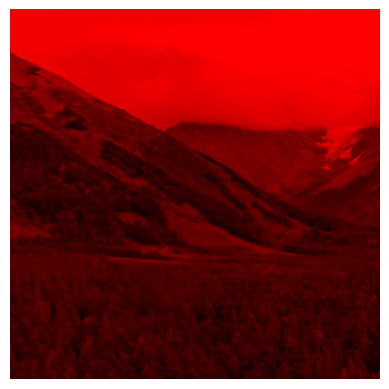

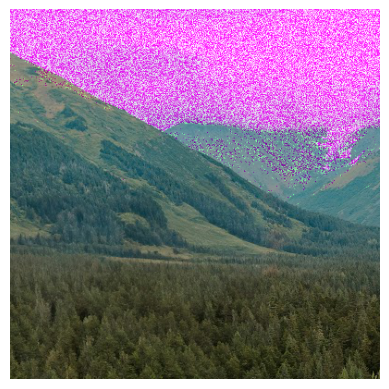

In [6]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import random
img_array = mpimg.imread("photo3.jpg")
random.seed(1)

print(img_array.size)
print(img_array.shape)
print(img_array)
print(img_array.ndim)
print(img_array.dtype)

plt.imshow(img_array)
plt.axis("off")
plt.show()

canvas = np.zeros(img_array.shape) 
plt.imshow(canvas)
plt.axis("off")
plt.show()


- Indexing, Slicing & Masking:
Slicing: Crop the image to focus on a specific subject (e.g., img[100:500, 200:600]).
Indexing: Isolate only the Red channel of the image.
Masking: Create a "green screen" effect. Find all pixels where the green value is high and replace them with pixels from a completely different background array.

In [ ]:
cropped_img = img_array[100:500, 200:600]
plt.imshow(cropped_img)
plt.axis("off")
plt.show()

red_channel = cropped_img.copy()
img_channel = cropped_img[:, :, 0]
red_channel[:, :, 1] = 0
red_channel[:, :, 2] = 0
plt.imshow(red_channel)
plt.axis("off")
plt.show()

result = cropped_img.copy() 
masking_screen = result[:, :, 1]> 150
random_cropped_green_img = np.random.randint(0,256, size = (len(result[masking_screen])))
#print(len(result[masking_screen]))
#print(result[masking_screen])
result[masking_screen, 1] = random_cropped_green_img
plt.imshow(result)
plt.axis("off")
plt.show()

- Vectorization, Broadcasting & Ufuncs: Increase the image's brightness by simply adding a scalar value (e.g., img + 50 demonstrating broadcasting). Apply a gamma correction or vintage filter using np.power() and np.sqrt() (ufuncs) without writing a single for loop.

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[ 72  74  52]
  [ 59  61  50]
  [ 85  87  63]
  ...
  [ 64  62  50]
  [ 66  64  52]
  [ 65  65  53]]

 [[ 67  70  50]
  [ 76  79  50]
  [110 113  82]
  ...
  [ 64  62  50]
  [ 66  64  52]
  [ 67  65  53]]

 [[ 90  94  61]
  [104 108  75]
  [104 108  75]
  ...
  [ 68  66  54]
  [ 67  65  53]
  [ 67  65  53]]]
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[ 72  74  52]
  [ 59  61  50]
  [ 85  87  63]
  ..

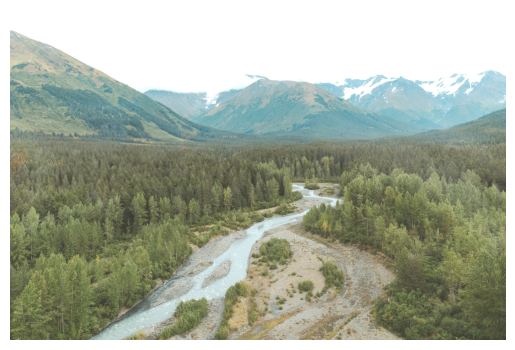

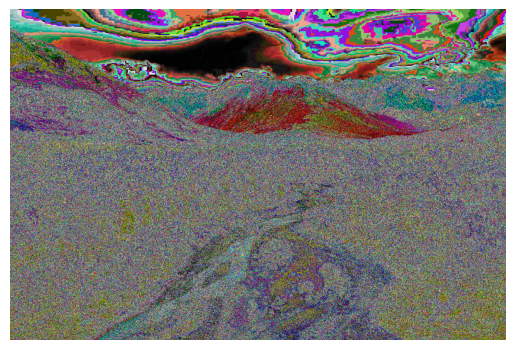

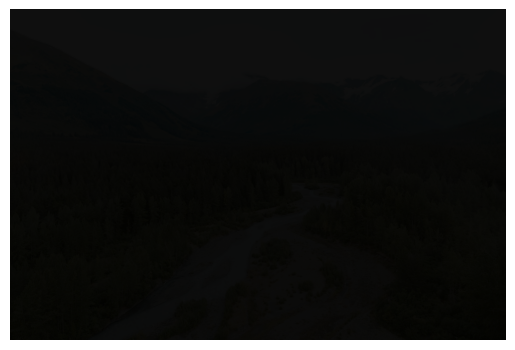

In [28]:
brightness = img_array.astype(np.int16) + 50
#brightness = img_array + 50
# print(img_array)
brightness = np.clip(brightness, 0, 255)
brightness = brightness.astype(np.uint8)
print(brightness)
print(brightness.clip())
plt.imshow(brightness)
plt.axis("off")
plt.show()

gamma = img_array.astype(np.int16)
gamma= np.power(img_array,2)
gamma = np.clip(gamma, 0, 255)
gamma = gamma.astype(np.uint8)
plt.imshow(gamma)
plt.axis("off")
plt.show() 

gamma2 = img_array.astype(np.int16)
gamma2 = np.sqrt(img_array)
gamma2 = np.clip(gamma2, 0, 255)
gamma2 = gamma2.astype(np.uint8)
plt.imshow(gamma2)
plt.axis("off")
plt.show()

- Math & Stats: Find the brightest and darkest pixels in the image (np.max, np.min). Calculate the average pixel intensity of the image to determine if it is "overexposed" or “underexposed” (np.mean across specific axes).

In [18]:

Max_pixel = np.max(img_array)
print(Max_pixel)
Min_pixel = np.min(img_array)
print(Min_pixel)

average = img_array.copy()
average_red = np.mean(average[:, :, 0])
if average_red > 200:
    print("Overexposed")
else:
    print("Underexposed")
average_green = np.mean(average[:, :, 1])
if average_green > 200:
    print("Overexposed")
else:
    print("Underexposed")
average_blue = np.mean(average[:, :, 2])
if average_blue > 200:
    print("Overexposed")
else:
    print("Underexposed")

255
0
Underexposed
Underexposed
Underexposed
